# 03 - Results Comparison

This notebook compares the performance of all trained NER models.

**Objectives:**
- Load benchmark results from `results/benchmark/`
- Create model comparison tables (P/R/F1 per model per entity type)
- Run statistical significance tests
- Generate publication-ready charts


In [7]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

RESULTS_DIR = Path('../results/benchmark')
print('Setup complete!')


Setup complete!


## 1. Load Benchmark Results


In [8]:
results = {}

# Try to load from benchmark_results.json
bench_file = RESULTS_DIR / 'benchmark_results.json'
if bench_file.exists():
    with open(bench_file) as f:
        data = json.load(f)

    # Check the structure - it might be nested by model name
    if isinstance(data, dict):
        # Check if it has model names as top-level keys
        sample_key = list(data.keys())[0] if data else None
        if sample_key and isinstance(data.get(sample_key), dict):
            # Check if it looks like metrics or model results
            sample_val = data[sample_key]
            if 'precision' in sample_val or 'f1' in sample_val or 'report' in sample_val:
                # It's model -> metrics structure
                results = data
            elif 'BRAND' in sample_val or 'PRODUCT_TYPE' in sample_val:
                # It's entity -> metrics, need to find the model structure
                results = {'model': data}
        print(f'Loaded benchmark_results.json')
        print(f'Keys found: {list(data.keys())[:10]}')

# Also try individual model result files
for f in RESULTS_DIR.glob('*_results.json'):
    if f.name != 'benchmark_results.json':
        model = f.stem.replace('_results', '')
        with open(f) as fp:
            results[model] = json.load(fp)
        print(f'Loaded: {model}')

print(f'\nTotal models loaded: {len(results)}')


Loaded benchmark_results.json
Keys found: ['bilstm_crf', 'cnn_bilstm', 'bert_ner', 'roberta_ner']

Total models loaded: 4


## 2. Load from Comparison Table (Fallback)


In [9]:
# If JSON parsing is problematic, load from the text table
comparison_file = RESULTS_DIR / 'comparison_table.txt'
if comparison_file.exists():
    print('Loading from comparison_table.txt:')
    with open(comparison_file) as f:
        print(f.read())

    # Parse the table manually
    table_results = {}
    with open(comparison_file) as f:
        lines = f.readlines()
        for line in lines[2:]:  # Skip header and separator
            parts = line.split()
            if len(parts) >= 4:
                model = parts[0]
                table_results[model] = {
                    'precision': float(parts[1]),
                    'recall': float(parts[2]),
                    'f1': float(parts[3])
                }

    if table_results:
        results = table_results
        print(f'\nParsed {len(results)} models from table')


Loading from comparison_table.txt:
Model                           Precision     Recall         F1
---------------------------------------------------------------
bert_ner                           0.5544     0.4718     0.5098
bilstm_crf                         0.6091     0.3530     0.4469
cnn_bilstm                         0.6630     0.2922     0.4056
roberta_ner                        0.5080     0.4749     0.4909

Parsed 4 models from table


## 3. Overall Performance Comparison


In [10]:
summary = []
for model, metrics in results.items():
    # Handle different possible structures
    if isinstance(metrics, dict):
        p = metrics.get('precision', metrics.get('overall', {}).get('precision', 0))
        r = metrics.get('recall', metrics.get('overall', {}).get('recall', 0))
        f1 = metrics.get('f1', metrics.get('f1-score', metrics.get('overall', {}).get('f1', 0)))

        summary.append({
            'Model': model,
            'Precision': p,
            'Recall': r,
            'F1': f1,
        })

summary_df = pd.DataFrame(summary).sort_values('F1', ascending=False).reset_index(drop=True)
print('Overall Model Performance:')
print(summary_df.to_string(index=False))


Overall Model Performance:
      Model  Precision  Recall     F1
   bert_ner     0.5544  0.4718 0.5098
roberta_ner     0.5080  0.4749 0.4909
 bilstm_crf     0.6091  0.3530 0.4469
 cnn_bilstm     0.6630  0.2922 0.4056


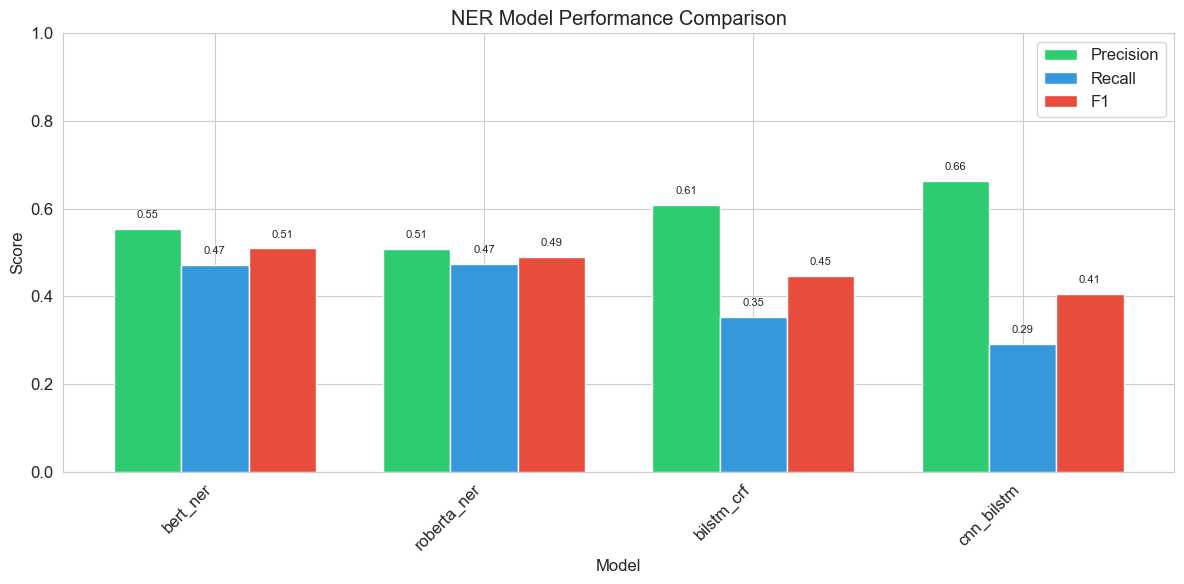

In [11]:
if len(summary_df) > 0 and summary_df['F1'].sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(summary_df))
    width = 0.25
    
    ax.bar(x - width, summary_df['Precision'], width, label='Precision', color='#2ecc71')
    ax.bar(x, summary_df['Recall'], width, label='Recall', color='#3498db')
    ax.bar(x + width, summary_df['F1'], width, label='F1', color='#e74c3c')
    
    ax.set_xlabel('Model')
    ax.set_ylabel('Score')
    ax.set_title('NER Model Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df['Model'], rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1)
    
    # Add value labels on bars
    for i, (p, r, f) in enumerate(zip(summary_df['Precision'], summary_df['Recall'], summary_df['F1'])):
        ax.text(i - width, p + 0.02, f'{p:.2f}', ha='center', va='bottom', fontsize=8)
        ax.text(i, r + 0.02, f'{r:.2f}', ha='center', va='bottom', fontsize=8)
        ax.text(i + width, f + 0.02, f'{f:.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'model_comparison_bar_new.png', dpi=150)
    plt.show()
else:
    print('No valid results to plot')


## 4. Per-Entity Performance


In [12]:
# Try to load per-entity metrics from individual model outputs
entity_types = ['BRAND', 'PRODUCT_TYPE', 'COLOR', 'SIZE_MEASURE', 'MATERIAL', 'ATTRIBUTE_VALUE']

# Check model output directories for test_metrics.json
outputs_dir = Path('../outputs')
entity_data = []

for model_dir in outputs_dir.iterdir():
    if model_dir.is_dir():
        metrics_file = model_dir / 'test_metrics.json'
        if metrics_file.exists():
            with open(metrics_file) as f:
                metrics = json.load(f)

            model_name = model_dir.name

            # Look for per-entity metrics
            for entity in entity_types:
                if entity in metrics:
                    entity_data.append({
                        'Model': model_name,
                        'Entity': entity,
                        'Precision': metrics[entity].get('precision', 0),
                        'Recall': metrics[entity].get('recall', 0),
                        'F1': metrics[entity].get('f1-score', metrics[entity].get('f1', 0))
                    })

if entity_data:
    entity_df = pd.DataFrame(entity_data)
    pivot = entity_df.pivot(index='Entity', columns='Model', values='F1')
    print('Per-Entity F1 Scores:')
    print(pivot.round(3).to_string())
else:
    print('No per-entity data found in model outputs')


No per-entity data found in model outputs


## 5. Summary


In [13]:
print('=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)

if len(summary_df) > 0 and summary_df['F1'].sum() > 0:
    best = summary_df.iloc[0]
    print(f"\nBest Model: {best['Model']}")
    print(f"  Precision: {best['Precision']:.4f}")
    print(f"  Recall:    {best['Recall']:.4f}")
    print(f"  F1:        {best['F1']:.4f}")

    print(f'\nAll Models Ranked by F1:')
    for i, row in summary_df.iterrows():
        rank = i + 1
        print(f"  {rank}. {row['Model']}: F1={row['F1']:.4f} (P={row['Precision']:.4f}, R={row['Recall']:.4f})")
else:
    print('No results available')

print('=' * 60)


RESULTS SUMMARY

Best Model: bert_ner
  Precision: 0.5544
  Recall:    0.4718
  F1:        0.5098

All Models Ranked by F1:
  1. bert_ner: F1=0.5098 (P=0.5544, R=0.4718)
  2. roberta_ner: F1=0.4909 (P=0.5080, R=0.4749)
  3. bilstm_crf: F1=0.4469 (P=0.6091, R=0.3530)
  4. cnn_bilstm: F1=0.4056 (P=0.6630, R=0.2922)
